In [1]:
using Revise
includet("../../scripts/single_influx.jl")

In [2]:
using ProgressMeter
using ColorSchemes
using UnPack

In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Run the li=1 data

In [34]:
N = 20
M = N
B = 3

Ks = 10 .^ range(-0.5, 4.0, 50)

li1df, li1cms = do_df_run(Ks, N;
    M,
    # Slightly random vars
    m=base10_lognormal(0.0, 0.001),
    c=base10_lognormal(0.0, 0.001),
    cinflux=base10_lognormal(0.0, 0.001),
    # Always eat influx with fixed l
    pei=1.0, linflux=1.0,
    # Eat rest with chance at no l
    pe=(B / M), l=0.0,
    # Rest
    num_byproducts=Binomial(M, B / M),
    # Rest 2
    num_repeats=100,
    lsks=10 .^ range(-5, 3, 2000),
)
li1cdf = make_counts_df(li1df)

Progress:  32%|█████████████▏                           |  ETA: 0:07:03┌ Warning: At t=3405.196714177244, dt was forced below floating point epsilon 4.547473508864641e-13, and step error estimate = 0.0011256226846675433. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:673
┌ Warning: At t=657.0197428369025, dt was forced below floating point epsilon 1.1368683772161603e-13, and step error estimate = 0.00036234893713551163. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:673
┌ Error: maxresid reached is 2.60066e+24 which is above the error threshold of 1e-08
└ @ SSMCMain.ModifiedMiCRM.RandomSystems

countmap(df.sscode) = Dict(1015 => 7, -1015 => 1, 2 => 1671, -2000 => 79, 1 => 3242)
countmap(df.lscode) = Dict{Union{Missing, Int64}, Int64}(missing => 87, 2 => 2272, 1 => 2601, 23 => 40)
count($(Expr(:.&&, :(df.good_ss), :(df.good_ls)))) / nrow(df) = 0.9746
prop_good_ss_and_ls = 0.9746


Row,K,num_runs,bad_ss,extinct,good_ss_bad_ls,nonext_stable,nonext_unstable
,Float64,Int64,Int64,Int64,Int64,Int64,Int64
1,0.316228,100,0,100,0,0,0
2,0.390694,100,0,100,0,0,0
3,0.482696,100,0,100,0,0,0
4,0.596362,100,0,100,0,0,0
5,0.736795,100,0,100,0,0,0
6,0.910298,100,0,100,0,0,0
7,1.12466,100,0,100,0,0,0
8,1.3895,100,0,100,0,0,0
9,1.7167,100,0,100,0,0,0


In [35]:
jldsave("../../data/forfigures/fig1/si_li1.jld2"; N, M, B, Ks, li1df, li1cdf, li1cms=l1cms)

# Load data (takes ~3min)

In [4]:
f = jldopen("../../cluster_env/runs/single_influx/gd5_forfigures_260212_153215.jld2");
Ks, lis, rslts = make_Kli_matrix(f);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


In [5]:
f2 = jldopen("../../data/forfigures/fig1/si_li1.jld2")
li1df = f2["li1df"]
li1cdf = f2["li1cdf"];

In [6]:
rdfs = f["raw_dfs"];

# Plot a sample SI dispersion relation

In [63]:
cK = Ks[22]
@show cK
xx = @subset li1df :K .== cK :lscode .== 2
@show nrow(xx)
# yy = rand(eachrow(xx));
yy = xx[1,:];

cK = 26.826957952797258
nrow(xx) = 95


In [80]:
ks = 10 .^ range(-5, 2, 2000)
lsfunc = linstab_make_k_func(yy.params, yy.steadystates)
lambdas = lsfunc.(ks);
# faa = plot_linstab_lambdas(ks, lambdas)
# display(GLMakie.Screen(), faa.figure)
# faa.figure

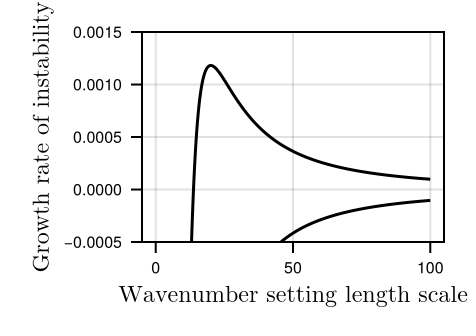

In [75]:
fig = Figure(;
    size=(double_col_width * 0.35, 0.4 * double_col_width / golden_ratio),
)
ax = Axis(fig[1,1];
    xlabel=L"\text{Wavenumber setting length scale}",
    ylabel=L"\text{Growth rate of instability}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
    # ylabel=L"\lambda,\enspace\text{growth rate}",
    # xlabel=L"k,\enspace\text{wavenumber}",
)

num_lambdas = length(lambdas[1])

for li in 1:num_lambdas
    ls = getindex.(lambdas, li)

    lines!(ax, ks, real(ls);
        color=:black,
    )
end

ylims!(ax, -0.0005, 0.0015)

Makie.save("../../figures/fig1/disprel_si_sample.pdf", fig)

fig

# Proportions plot

In [30]:
lis

1-element Vector{Float64}:
 1.0

In [24]:
li1xx = [(; extinct=r.extinct, nonext_stable=r.nonext_stable, nonext_unstable=r.nonext_unstable, num_runs=r.num_runs) for r in eachrow(li1cdf)];

In [26]:
?plot_binom_sample!

search: plot_binom_sample! plot_binom_sample



No documentation found.

`SSMCMain.plot_binom_sample!` is a `Function`.

```
# 1 method for generic function "plot_binom_sample!" from SSMCMain:
 [1] plot_binom_sample!(ax, xs, ns, num_repeats; proportions, kwargs...)
     @ ~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/src/SSMCMain/src/util.jl:257
```


In [61]:
lis[end-20]

0.8950575225478374

LoadError: UndefVarError: `extinct` not defined

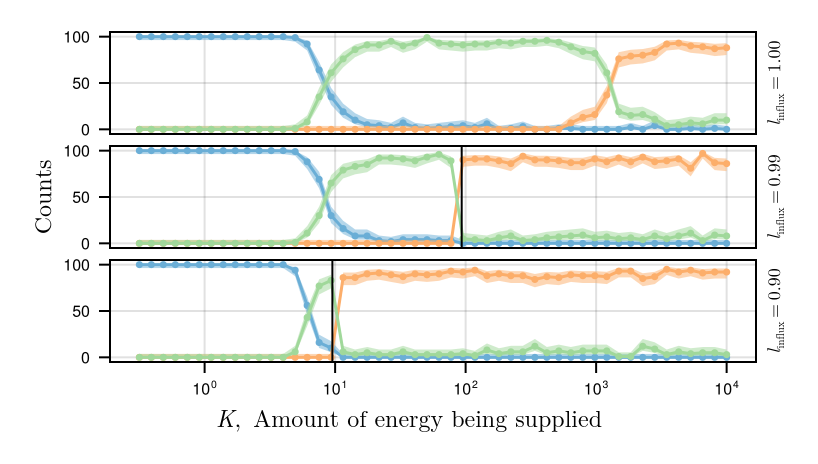

In [122]:
faflis = [1.]
fafcounts = Any[li1xx]

for i in [length(lis)-10, length(lis)-20]
    push!(faflis, lis[i])
    push!(fafcounts, rslts[:,i])
end

fig = Figure(;
   size=(double_col_width * 0.60, 0.55 * double_col_width / golden_ratio),
)

axs = []
for i in 1:length(faflis)
    li = faflis[i]
    cs = fafcounts[i]

    ax = Axis(fig[i,1];
        xscale=log10,
        xticklabelsize=6fontsize_pt,
        yticklabelsize=6fontsize_pt,
    )
    ylims!(ax, -5, 105)
    push!(axs, ax)
    Label(fig[i,2], latexstring(@sprintf "l_\\text{influx}=%.2f" li);
        rotation=pi/2,
        tellheight=false,
        fontsize=6fontsize_ltex_pt,
    )
    
    num_runs = [x.num_runs for x in cs]
    plot_binom_sample!(ax, Ks, [x.extinct for x in cs], num_runs;
        color=PaperColors.extinct1(),
        sl_kwargs=(; markersize=5.),
    )
    plot_binom_sample!(ax, Ks, [x.nonext_stable for x in cs], num_runs;
        color=PaperColors.stable1(),
        sl_kwargs=(; markersize=5.),
    )
    plot_binom_sample!(ax, Ks, [x.nonext_unstable for x in cs], num_runs;
        color=PaperColors.unstable1(),
        sl_kwargs=(; markersize=5.),
    )
        
    thrbdr = 1 / (1 - li)
    if isfinite(thrbdr)
        vlines!(ax, thrbdr;
            color=:black,
            linewidth=1.,
        )
    end
end

for i in 1:(length(axs)-1)
    linkxaxes!(axs[end], axs[i])
    hidexdecorations!(axs[i]; grid=false)
end

Label(fig[:,0], L"\text{Counts}";
    rotation=pi/2,
    tellheight=false,
    fontsize=8fontsize_ltex_pt,
)

Label(fig[end+1,:], L"K,\enspace\text{Amount of energy being supplied}";
    tellwidth=false,
    fontsize=8fontsize_ltex_pt,
)

rowgap!(fig.layout, 6.)
colgap!(fig.layout, 5.)

Makie.save("../../figures/fig1/proportions.pdf", fig)

fig

# Plotting dominant states as a K vs l phase diagram

In [7]:
extrema(1 .- lis)

(0.0010000000000000009, 0.5)

In [8]:
dominant = map(rslts) do x
    am = argmax([x.extinct, x.nonext_unstable, x.nonext_stable])
    if am == 1
        PaperColors.extinct1()
    elseif am == 2
        PaperColors.unstable1()
    else
        PaperColors.stable1()
    end
end;

In [9]:
default_fig_kwargs = (;
    fontsize=6fontsize_pt,
    markersize=6,
    figure_padding=(2, 2, 2, 2)
)

(fontsize = 8.0, markersize = 6, figure_padding = (2, 2, 2, 2))

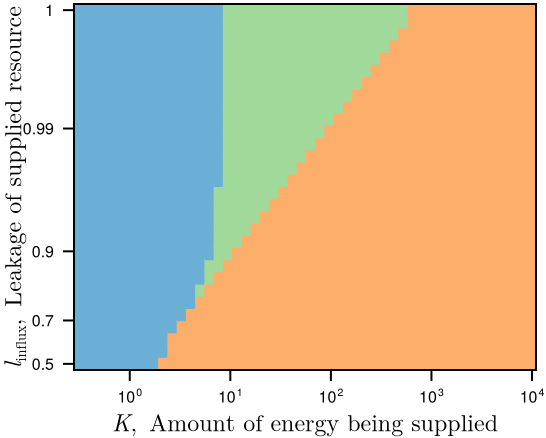

In [12]:
fig = Figure(;
    size=(double_col_width * 0.4, (double_col_width / golden_ratio) * 0.52),
    figure_padding=(2., 5., 2., 2.),
)
ax = Axis(fig[1,1];
    xscale=log10,
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

heatmap!(ax, Ks, LeakageScale.ltox.(lis), dominant)
eps_ticks = [0.5, 0.3, 0.1, 0.01, 0.001]
ax.yticks = (LeakageScale.etox.(eps_ticks), [(@sprintf "%.2g" (1-e)) for e in eps_ticks])
ax.ylabel = L"l_\text{influx},\enspace\text{Leakage of supplied resource}"
ax.xlabel = L"K,\enspace\text{Amount of energy being supplied}"

ax.ylabelpadding = -3.

Makie.save("../../figures/fig1/K_vs_l_pd.pdf", fig)

fig